# T11a — RNN (Vanilla Recurrent Neural Network)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** Vanilla RNN → known to suffer from vanishing gradients on long sequences.

In [1]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [2]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")


Device: mps


In [3]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False   # required for full reproducibility
print(f"Seeds fixed: {SEED}")


Seeds fixed: 42


## 1. Load data & build windows

In [4]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

# Engine-level train/val split (no leakage)
X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)

# Test windows (last window per engine)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 123)  (249 engines)
Test  shape : (41214, 123)   (248 engines)
Feature columns (48): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's6_rmean_5', 's7_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (43750, 30, 48)  X_val: (50, 30, 48)
Train batches: 342  Val batches: 1


## 2. Model definition

Vanilla RNN — simplest recurrent architecture. Susceptible to vanishing gradients for long sequences.

In [5]:
from src.models.dl_architectures import RNNModel

model = RNNModel(n_features=N_FEATURES, dropout=0.1)

## 3. Train

In [6]:
model, train_losses, val_losses = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "RNN",
)


  [RNN] Epoch  10 | train=3.8220 | val=3.4661 | best=1.2139  [NASALoss]
  [RNN] Early stop at epoch 15


## 4. Evaluate

In [7]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
results = evaluate(y_true, y_pred, model_name="RNN")
print(results)


  [RNN] RMSE: 15.6686  |  NASA Score: 978.55 (mean: 3.95)  |  R2: 0.8671  |  Bias: -3.50 (early ↓)
{'rmse': 15.66856575012207, 'nasa_score': 978.5479125976562, 'nasa_score_mean': 3.9457577120873237, 'r2_score': 0.8671069145202637, 'bias': -3.4988675117492676}


In [8]:
from src.evaluation.metrics import save_model_results, save_predictions_csv

save_model_results(
    model_name = "RNN",
    model_type = "dl",
    y_true     = y_true,
    y_pred     = y_pred,
)

# Save per-engine predictions CSV (point model: lower=upper=pred, width=0)
engine_ids = list(range(len(y_true)))
save_predictions_csv(
    engine_ids = engine_ids,
    y_true     = y_true,
    y_pred     = y_pred,
    y_lower    = y_pred,
    y_upper    = y_pred,
    model_name = "RNN",
)


  [RNN] RMSE: 15.6686  |  NASA Score: 978.55 (mean: 3.95)  |  R2: 0.8671  |  Bias: -3.50 (early ↓)
  → Saved to results/all_model_results.csv

  [RNN] Bound Validation Report (248 engines):
    ✓ negative_preds: 0
    ✓ over_cap_preds: 0
    ✓ inverted_bounds: 0
    ✓ pred_outside_interval: 0
    ✓ nan_or_inf: 0
    → All checks passed — predictions are numerically valid.
  → Saved 248 predictions to results/predictions/RNN.csv
     Coverage: 0.0%  |  Avg interval width: 0.00 cycles


PosixPath('/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/results/predictions/RNN.csv')

## 5. Plots

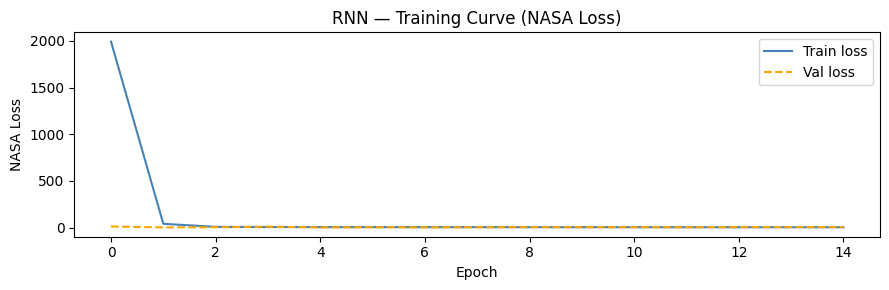

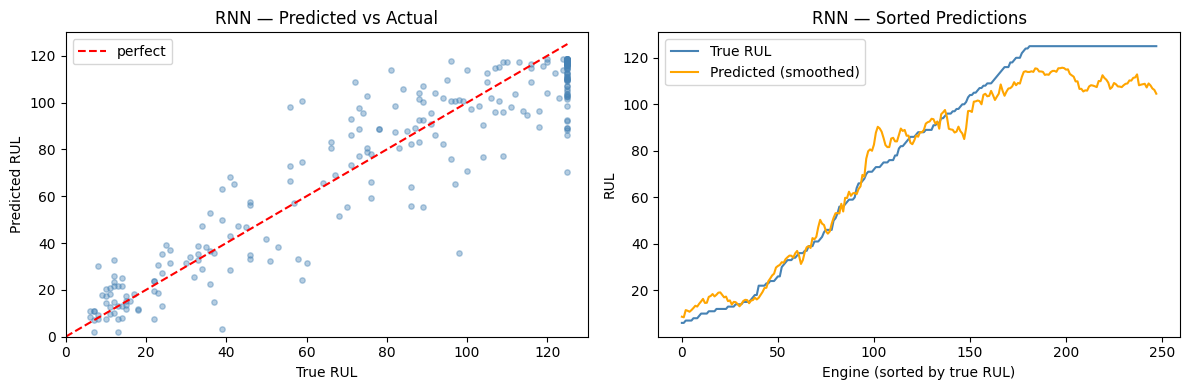

In [9]:
plot_loss_curves(train_losses, val_losses, model_name="RNN")
plot_predictions(y_true, y_pred, model_name="RNN")
